# Analyze single sample

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re 
import os
import sys

In [69]:
# data_folder = "/data/proj/pangebin/data"

data_folder = "./test_data/"
result_csv = "result.csv"
test_id = 'test_data'

In [86]:
def read_score_to_tuple(sample, score, input_type):
    cols = ["sample", "model", "bintype", "tool", "prec", "rec", "f1"]
    # out_tuple = pd.DataFrame(columns=cols)
    # voglio leggere i file .txt del typo "score" (lab o bin) e del tipo "input_type" (ske, uni, pan)
    # e metterli in un dataframe
    # se input type == pan allora devo fare la "media" dei valori di ske e uni
    # riguardo al tipo di bin: uni e ske hanno solo pred, mentre pan ha anche naive e graph-overlap
    for filename in os.listdir(sample):
        out_tuple = pd.DataFrame(columns=cols)
        fields = filename.split(".")
        if (not filename.endswith(".txt")): # salto i file non txt, non sono file di score
            continue
        _sample = fields[0] #nome del sample
        _type = fields[1] # tipo in input {ske, uni, pan}
        _thr = fields[2] # threshold (default 1)
        _model = fields[3] # modello {pbf, ml}, default pbf
        assert(_model == "pbf")
        _score = fields[-2] # score {lab, bin} labeling o binning
        _ref = fields[-3] # reference {uni, ske}
        _bins = fields[-4] # tipo di binning {pred, nve, ovl} pred= predizione del modello, nve= naive, ovl= graph-overlap
        
        if _type == input_type:
            if _score == "lab" and score == "lab": # se il tipo di score del file è del tipo richiesto
                assert(filename.endswith(".txt"))
                with open(sample+ "/" + filename) as file:
                    lines = file.readlines()
                    prec, rec, f1 = float(lines[-4].split("\t")[-1].strip()), float(lines[-3].split("\t")[-1].strip()), float(lines[-2].split("\t")[-1].strip())

            elif _score == "bin" and score == "bin":
                assert(filename.endswith(".txt"))
                with open(sample+ "/" + filename) as file:
                    lines = file.readlines()
                    prec, rec, f1 = float(lines[-3].split("\t")[-1].strip()), float(lines[-2].split("\t")[-1].strip()), float(lines[-1].split("\t")[-1].strip())
            else:
                continue
            print(filename, _sample, _model, _bins, f"{_thr}.{_type}.{_ref}", prec, rec, f1)
            out_tuple = pd.concat([pd.DataFrame([[_sample, _model, _bins, f"{_thr}.{_type}", prec, rec, f1]], columns=cols), out_tuple if not out_tuple.empty else None], ignore_index=True)

        else:
            continue
        # print(out_tuple)
        # out_tuple = out_tuple.groupby(["sample", "model", "bintype"]).mean(numeric_only=True).reset_index()
        # out_tuple.insert(loc=3, column="tool", value = f"{_thr}.{_type}")
    return out_tuple

In [ ]:
#iterate over all samples
df_labeling = pd.DataFrame(columns=["sample", "model", "bintype", "tool", "prec", "rec", "f1"])
df_binning = pd.DataFrame(columns=["sample", "model", "bintype", "tool", "prec", "rec", "f1"])
for file in os.listdir(data_folder):
    sample = data_folder + file
    for input_type in ["ske", "uni", "pan"]:
        df_labeling = pd.concat([read_score_to_tuple(sample, "lab", input_type), df_labeling if not df_labeling.empty else None], ignore_index=True)
        df_binning = pd.concat([read_score_to_tuple(sample, "bin", input_type), df_binning if not df_binning.empty else None], ignore_index=True)

# a


SAMEA3357328.uni.1.pbf.pred.uni.lab.txt SAMEA3357328 pbf pred 1.uni.uni 0.9944185135620328 1.0 0.997201446737476
SAMEA3357328.uni.1.pbf.pred.ske.lab.txt SAMEA3357328 pbf pred 1.uni.ske 0.0 0.0 0.0
SAMEA3357328.uni.1.pbf.pred.ske.bin.txt SAMEA3357328 pbf pred 1.uni.ske 0.0 0.0 0.0
SAMEA3357328.uni.1.pbf.pred.uni.bin.txt SAMEA3357328 pbf pred 1.uni.uni 0.9851121324803104 1.0 0.9925002385124271
SAMEA3357328.pan.1.pbf.ovl.ske.lab.txt SAMEA3357328 pbf ovl 1.pan.ske 0.9943902896241447 0.9907963428187192 0.9925900630125323
SAMEA3357328.pan.1.pbf.ovl.uni.lab.txt SAMEA3357328 pbf ovl 1.pan.uni 0.9943871857152236 1.0 0.9971856947713171
SAMEA3357328.pan.1.pbf.pred.ske.lab.txt SAMEA3357328 pbf pred 1.pan.ske 0.9943901844631073 0.9907776646712179 0.9925806376160736
SAMEA3357328.pan.1.pbf.pred.uni.lab.txt SAMEA3357328 pbf pred 1.pan.uni 0.9943871857152236 1.0 0.9971856947713171
SAMEA3357328.pan.1.pbf.nve.uni.lab.txt SAMEA3357328 pbf nve 1.pan.uni 0.0 0.0 0.0
SAMEA3357328.pan.1.pbf.nve.ske.lab.txt SA

/var/folders/6n/y0nbk78d0bv2s9s2m1qftmf40000gn/T/ipykernel_4899/3111789713.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_labeling = pd.concat([read_score_to_tuple(sample, "lab", input_type), df_labeling if not df_labeling.empty else None], ignore_index=True)
/var/folders/6n/y0nbk78d0bv2s9s2m1qftmf40000gn/T/ipykernel_4899/3111789713.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_labeling = pd.concat([read_score_to_tuple(sample, "lab", input_type), df_labeling if not df_labeling.e

SAMEA3357010.uni.1.pbf.pred.uni.bin.txt SAMEA3357010 pbf pred 1.uni.uni 0.7932557754183047 1.0 0.8847101303585826
SAMEA3357010.pan.1.pbf.pred.uni.lab.txt SAMEA3357010 pbf pred 1.pan.uni 0.9937082958827136 1.0 0.9968442203253707
SAMEA3357010.pan.1.pbf.pred.ske.lab.txt SAMEA3357010 pbf pred 1.pan.ske 0.993707808984082 0.9911883286919656 0.9924464698170923
SAMEA3357010.pan.1.pbf.ovl.uni.lab.txt SAMEA3357010 pbf ovl 1.pan.uni 0.9937082958827136 1.0 0.9968442203253707
SAMEA3357010.pan.1.pbf.ovl.ske.lab.txt SAMEA3357010 pbf ovl 1.pan.ske 0.993707808984082 0.9911883286919656 0.9924464698170923
SAMEA3357010.pan.1.pbf.nve.ske.lab.txt SAMEA3357010 pbf nve 1.pan.ske 0.9936442843656611 0.981218789523374 0.9873924474187381
SAMEA3357010.pan.1.pbf.nve.uni.lab.txt SAMEA3357010 pbf nve 1.pan.uni 0.9937082958827136 1.0 0.9968442203253707
SAMEA3357010.pan.1.pbf.nve.uni.bin.txt SAMEA3357010 pbf nve 1.pan.uni 0.6805331370327494 1.0 0.8099014795201714
SAMEA3357010.pan.1.pbf.nve.ske.bin.txt SAMEA3357010 pbf 

/var/folders/6n/y0nbk78d0bv2s9s2m1qftmf40000gn/T/ipykernel_4899/3111789713.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_labeling = pd.concat([read_score_to_tuple(sample, "lab", input_type), df_labeling if not df_labeling.empty else None], ignore_index=True)
/var/folders/6n/y0nbk78d0bv2s9s2m1qftmf40000gn/T/ipykernel_4899/3111789713.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_labeling = pd.concat([read_score_to_tuple(sample, "lab", input_type), df_labeling if not df_labeling.e

In [81]:
df_labeling.to_csv(f"{test_id}.labeling.csv", sep='\t', index=False)
df_binning.to_csv(f"{test_id}.binning.csv", sep='\t', index=False)
pd.set_option('display.max_rows', 1000)
print(df_binning)


Empty DataFrame
Columns: [sample, model, bintype, tool, prec, rec, f1]
Index: []


<Figure size 1000x600 with 0 Axes>

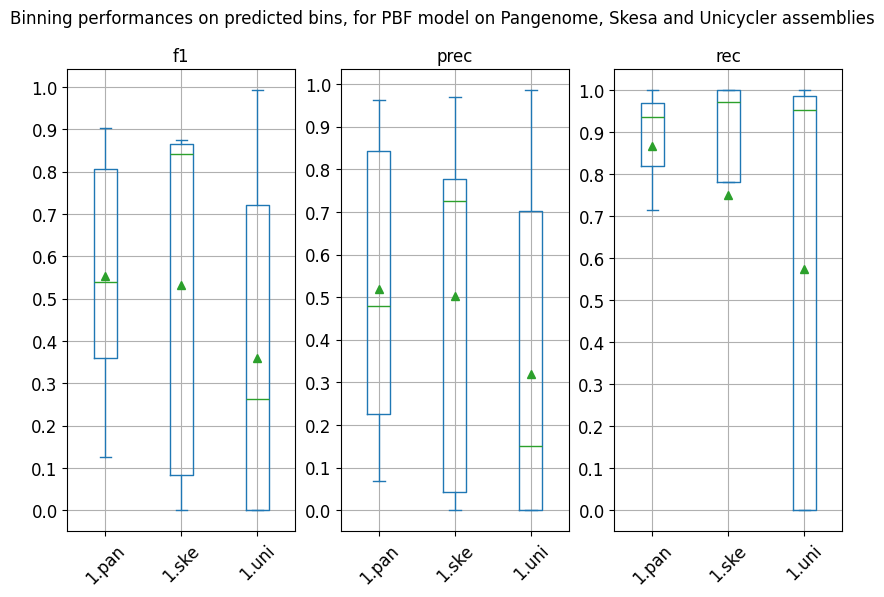

In [76]:
#Plotting pdf.bintype=pred
plt.figure(figsize=(10, 6))
plt.show()

plot_1 = df_binning.loc[df_binning["bintype"]=='pred'].plot.box(by=["tool"], figsize=(10, 6), rot=45, fontsize=12, grid=True, showmeans=True, showfliers=False, yticks=np.arange(0, 1.1, 0.1), title="Binning performances on predicted bins, for PBF model on Pangenome, Skesa and Unicycler assemblies")



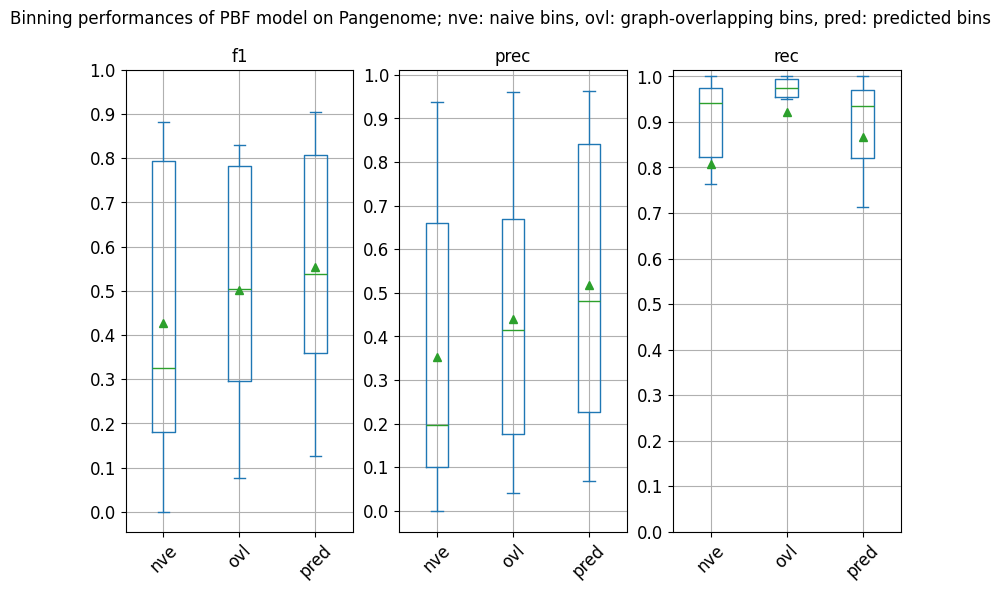

In [67]:
plot_2 = df_binning.loc[df_binning["tool"]=='1.pan'].plot.box(by=["bintype"], figsize=(10, 6), rot=45, fontsize=12, grid=True, showmeans=True, showfliers=False, yticks=np.arange(0, 1.1, 0.1), title = "Binning performances of PBF model on Pangenome; nve: naive bins, ovl: graph-overlapping bins, pred: predicted bins")


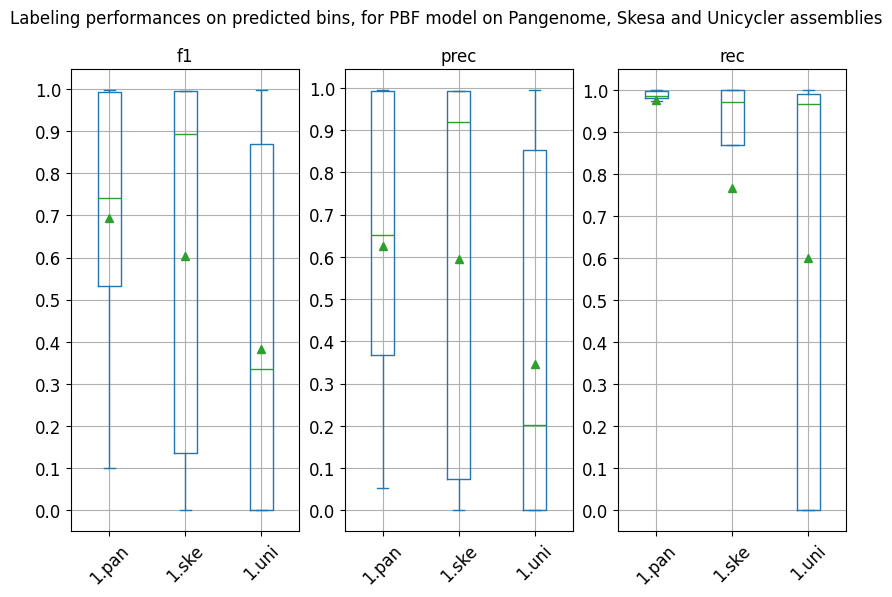

In [63]:
plot_3 = df_labeling.loc[df_labeling["bintype"]=='pred'].plot.box(by=["tool"], figsize=(10, 6), rot=45, fontsize=12, grid=True, showmeans=True, showfliers=False, yticks=np.arange(0, 1.1, 0.1), title="Labeling performances on predicted bins, for PBF model on Pangenome, Skesa and Unicycler assemblies")


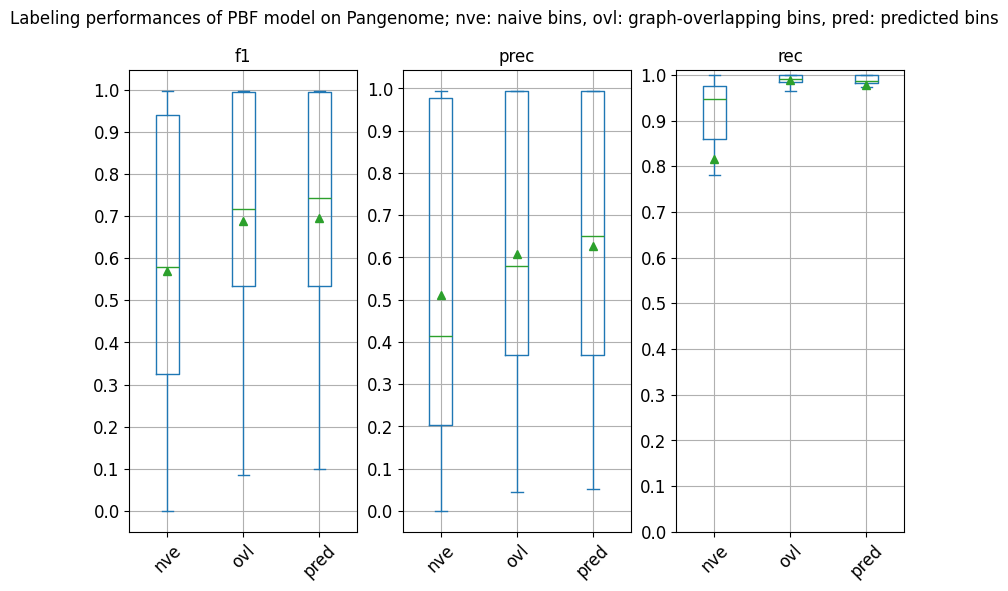

In [64]:
plot_4 = df_labeling.loc[df_labeling["tool"]=='1.pan'].plot.box(by=["bintype"], figsize=(10, 6), rot=45, fontsize=12, grid=True, showmeans=True, showfliers=False, yticks=np.arange(0, 1.1, 0.1), title = "Labeling performances of PBF model on Pangenome; nve: naive bins, ovl: graph-overlapping bins, pred: predicted bins")